**Un ejemplo de proceso de EDA (Exploratory Data Analysis) sobre el dataset de transporte público en Chicago**

In [1]:
# MUY IMPORTANTE: SI DECIDES EJECUTAR ESTE NOTEBOOK EN VSCODE, EN LUGAR DE GOOGLE COLAB,
# DEBERÁS DESCOMENTAR ESTAS DOS INSTRUCCIONES PARA EVITAR ERRORES:

# import ssl

# ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset desde la URL
url = "https://raw.githubusercontent.com/gakudo-ai/open-datasets/main/CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(url, parse_dates=["service_date"])


In [3]:
pd.set_option('display.float_format', '{:.0f}'.format) # Evita que valores grandes se muestren en notación científica
# Se puede revertir este ajuste en cualquier momento posterior con: pd.reset_option('display.float_format')

Inspección inicial del dataset mediante tres funciones.

In [4]:
# Vista preliminar de los datos
df.head()

,service_date,day_type,bus,rail_boardings,total_rides
0,2001-01-01,U,297192,126455,423647
1,2001-01-02,W,780827,501952,1282779
2,2001-01-03,W,824923,536432,1361355
3,2001-01-04,W,870021,550011,1420032
4,2001-01-05,W,890426,557917,1448343


In [5]:
# Información sobre el número de instancias, tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8036 entries, 0 to 8035
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   service_date    8036 non-null   datetime64[ns]
 1   day_type        8036 non-null   object        
 2   bus             8036 non-null   int64         
 3   rail_boardings  8036 non-null   int64         
 4   total_rides     8036 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 314.0+ KB


In [6]:
# Estadísticas descriptivas básicas de los atributos
df.describe()

,service_date,bus,rail_boardings,total_rides
count,8036,8036,8036,8036
mean,2011-12-05 00:20:36.436037888,737148,530454,1267602
min,2001-01-01 00:00:00,80783,23544,110047
25%,2006-07-02 18:00:00,475264,338196,827475
50%,2011-12-01 12:00:00,819968,602002,1506496
75%,2017-05-01 06:00:00,971227,706960,1644321
max,2022-10-31 00:00:00,1211992,1146516,2049519
std,NaN,268307,208199,461997


In [7]:
# Distribución de los atributos según tipo de dato
df.dtypes.value_counts()

,count
int64,3
datetime64[ns],1
object,1


In [8]:
# Detección de valores perdidos
df.isnull().sum()

,0
service_date,0
day_type,0
bus,0
rail_boardings,0
total_rides,0


In [9]:
# Detección de registros duplicados
print(f"Duplicados: {df.duplicated().sum()}")

# Se podrán eliminar en la posterior etapa de limpieza con: df = df.drop_duplicates()

Duplicados: 62


**Visualizaciones de distribuciones de los datos**

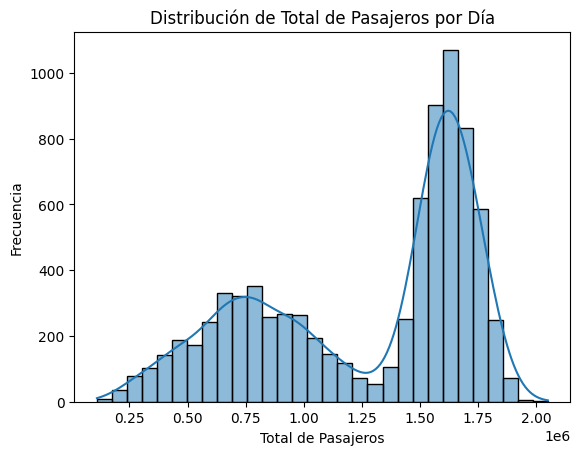

In [10]:
sns.histplot(df["total_rides"], bins=30, kde=True)
plt.title("Distribución de Total de Pasajeros por Día")
plt.xlabel("Total de Pasajeros")
plt.ylabel("Frecuencia")
plt.show()
# PROPUESTO: construye un gráfico múltiple que contenga el mismo tipo de histograma (o diagrama de barras) para cada atributo del dataset

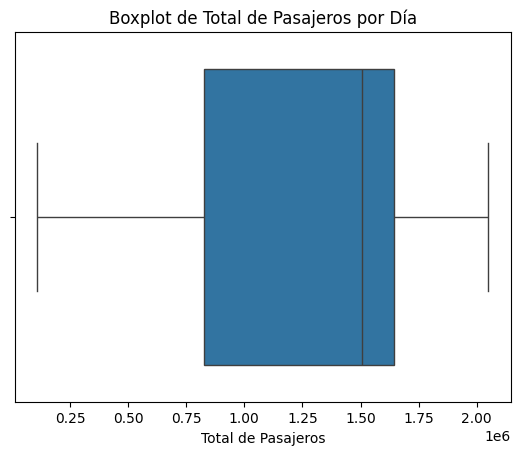

In [11]:
sns.boxplot(x=df["total_rides"])
plt.title("Boxplot de Total de Pasajeros por Día")
plt.xlabel("Total de Pasajeros")
plt.show()

In [12]:
# Detección manual de outliers con el método del rango intercuartílico (IQR)
Q1 = df["total_rides"].quantile(0.25)
Q3 = df["total_rides"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["total_rides"] < (Q1 - 1.5 * IQR)) | (df["total_rides"] > (Q3 + 1.5 * IQR))]
print(f"Número de outliers detectados: {outliers.shape[0]}")

# PROPUESTO: construye un gráfico múltiple que contenga varios boxplots, uno por cada atributo del dataset

Número de outliers detectados: 0


Análisis un poco más profundo, de cómo varía el número de pasajeros a lo largo del tiempo, y también en función del día de la semana.

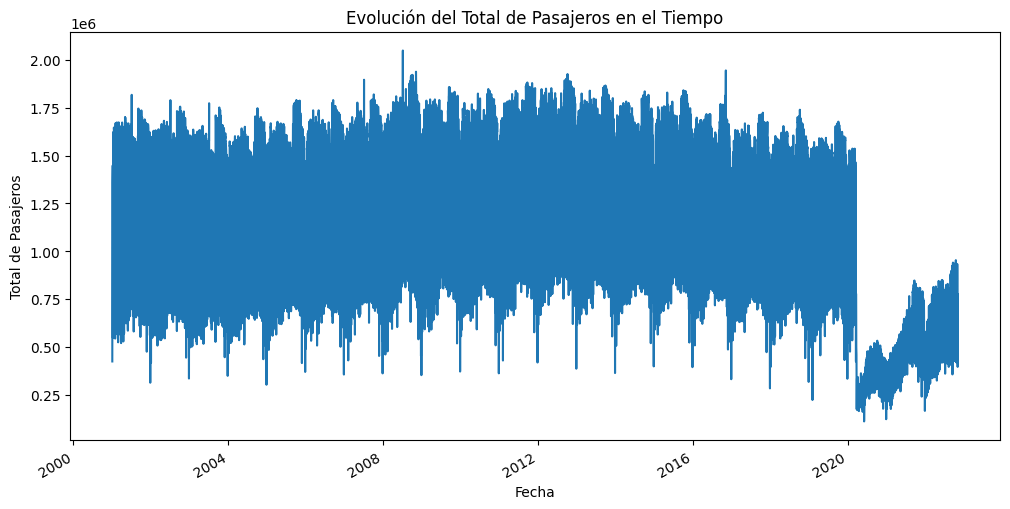

In [13]:
df = df.sort_values(by="service_date")
df.set_index("service_date")["total_rides"].plot(figsize=(12,6))
plt.title("Evolución del Total de Pasajeros en el Tiempo")
plt.xlabel("Fecha")
plt.ylabel("Total de Pasajeros")
plt.show()


In [14]:
# Para un análisis más profundo según el día de la semana
# añadiremos un nuevo atributo que contiene el dia de la semana
df["day_of_week"] = df["service_date"].dt.day_name()
df

,service_date,day_type,bus,rail_boardings,total_rides,day_of_week
0,2001-01-01,U,297192,126455,423647,Monday
1,2001-01-02,W,780827,501952,1282779,Tuesday
2,2001-01-03,W,824923,536432,1361355,Wednesday
3,2001-01-04,W,870021,550011,1420032,Thursday
4,2001-01-05,W,890426,557917,1448343,Friday
...,...,...,...,...,...,...
8031,2022-10-27,W,528826,395129,923955,Thursday
8032,2022-10-28,W,501985,352842,854827,Friday
8033,2022-10-29,A,311437,254149,565586,Saturday
8034,2022-10-30,U,217204,177961,395165,Sunday


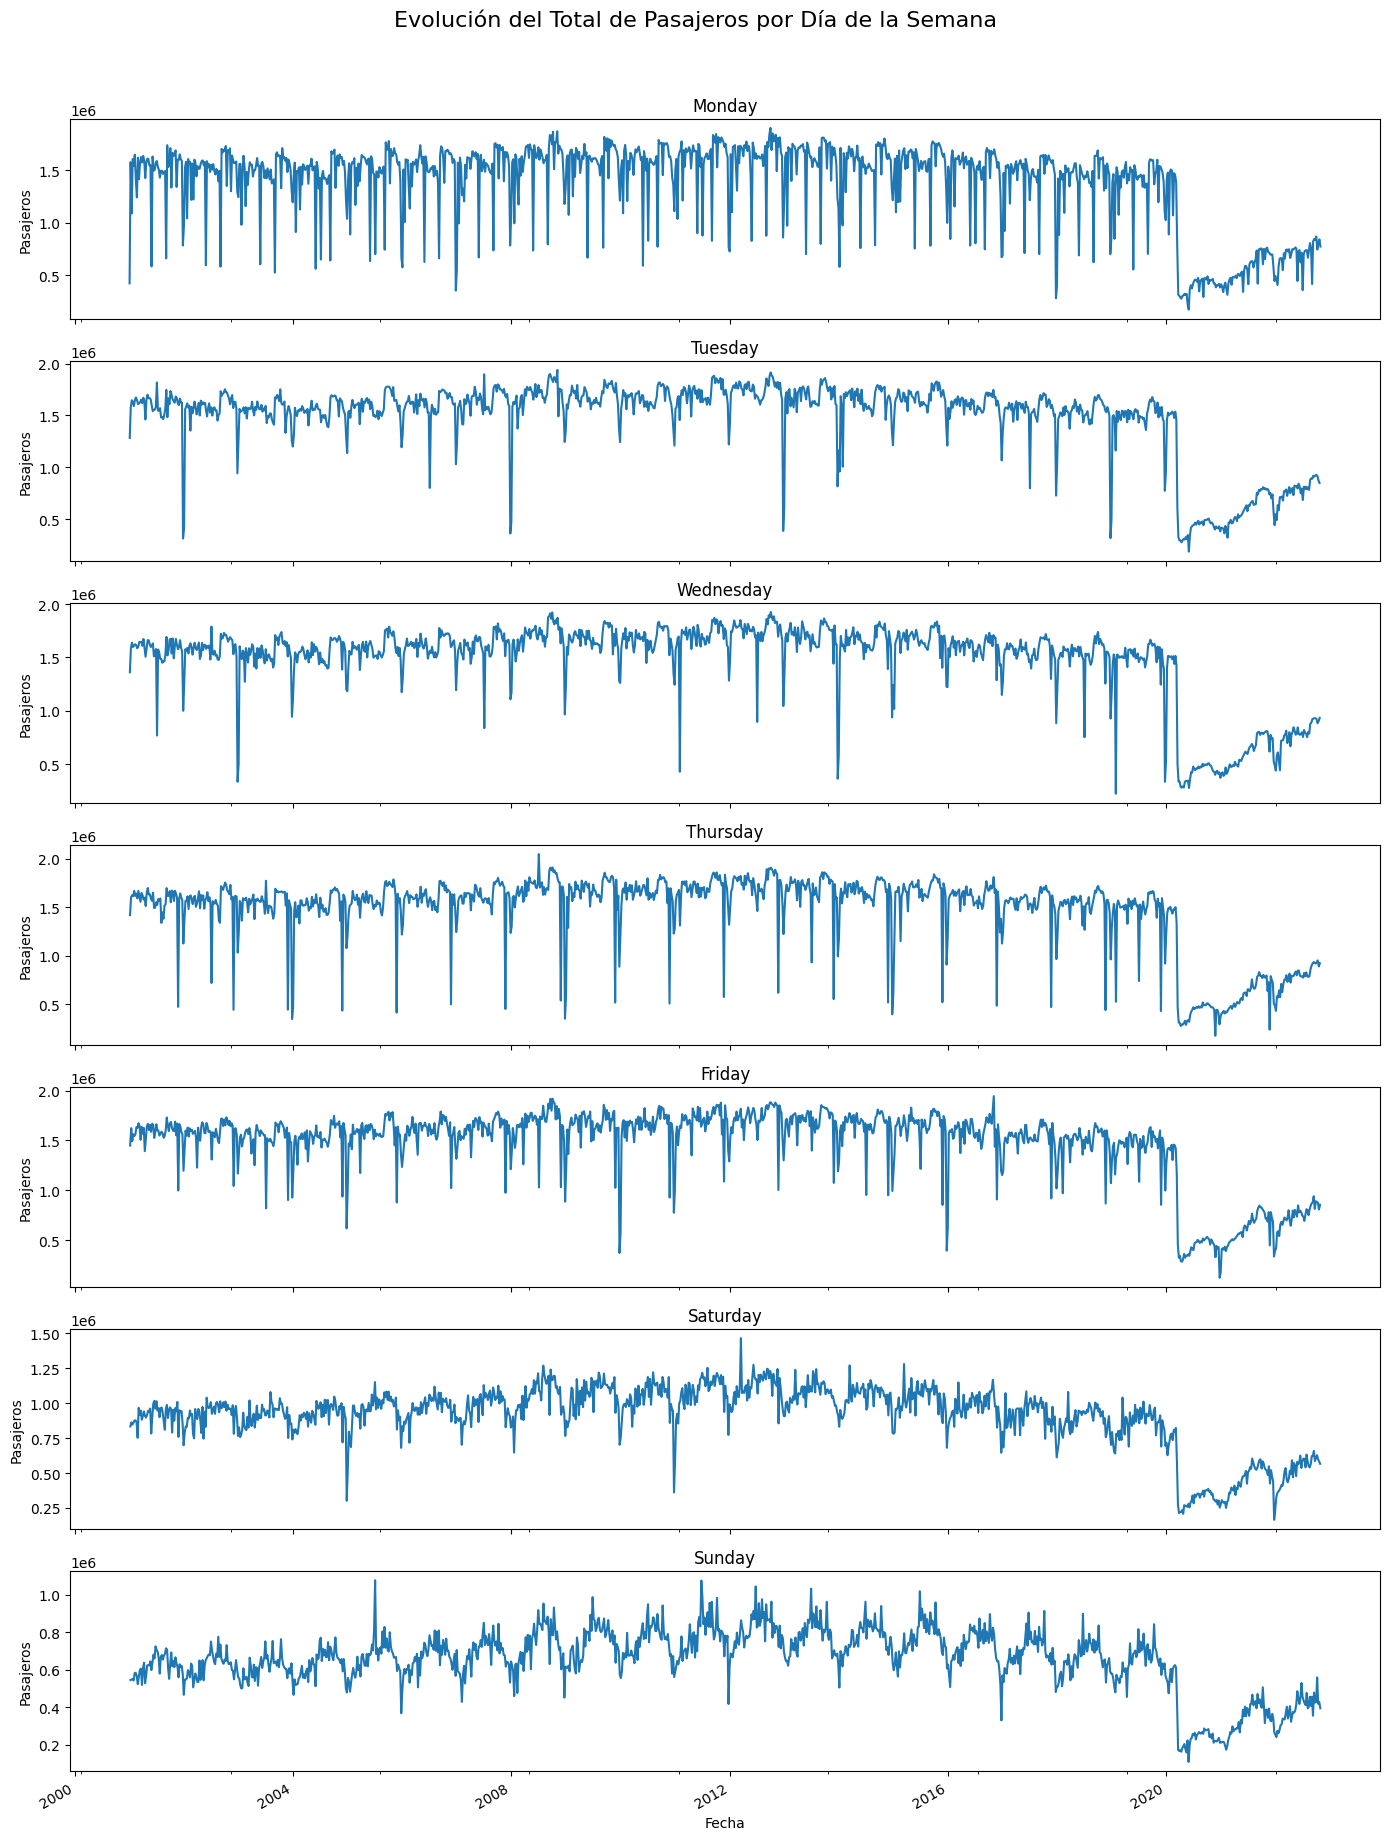

In [15]:
# Asegurarse de que la columna de fecha es el índice
df = df.set_index("service_date")

# Días ordenados
dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Crear la figura con 7 subplots (comparten eje x)
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(14, 18), sharex=True)

# Crear un gráfico por día
for i, dia in enumerate(dias):
    ax = axes[i]
    df[df["day_of_week"] == dia]["total_rides"].plot(ax=ax)
    ax.set_title(f"{dia}")
    ax.set_ylabel("Pasajeros")

# Etiqueta general del eje X
plt.xlabel("Fecha")
plt.suptitle("Evolución del Total de Pasajeros por Día de la Semana", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


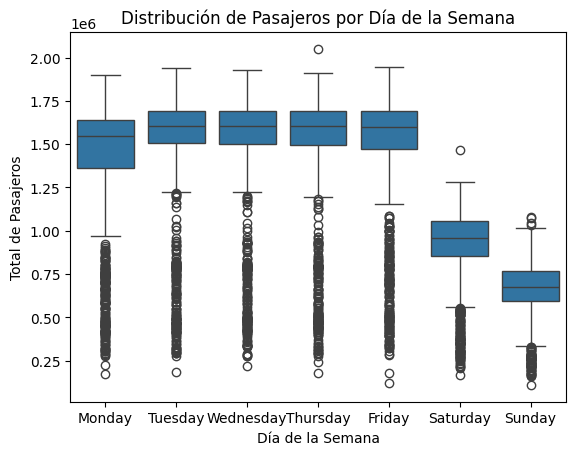

In [16]:
# Boxplot de pasajeros totales por día de la semana

sns.boxplot(x="day_of_week", y="total_rides", data=df,
            order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.title("Distribución de Pasajeros por Día de la Semana")
plt.xlabel("Día de la Semana")
plt.ylabel("Total de Pasajeros")
plt.show()


**Análisis de correlaciones entre variables**

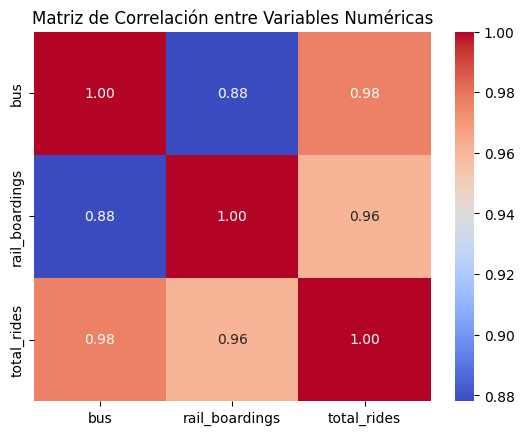

In [17]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()

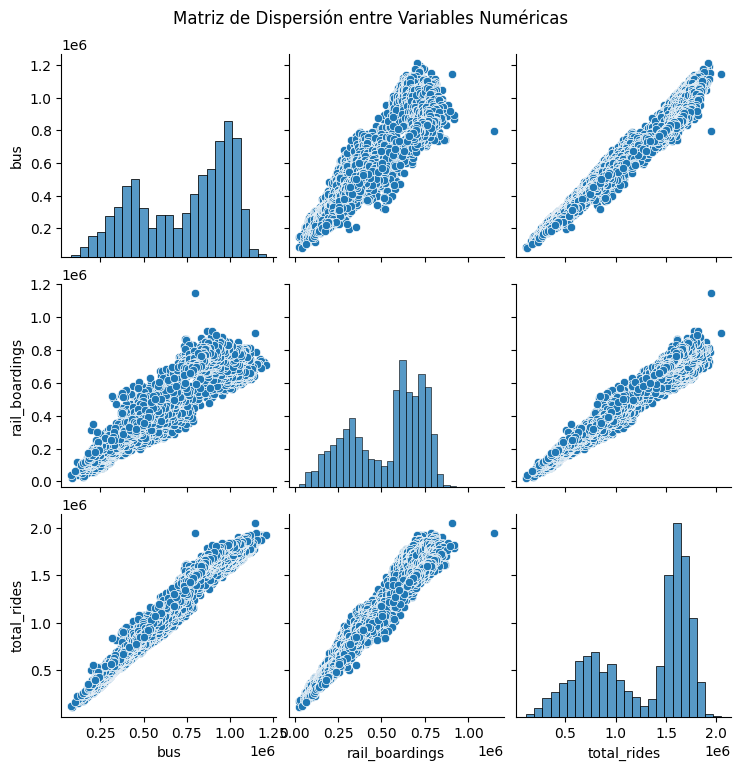

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include='number')

# Crear la matriz de dispersión: una versión más rica en información
# de la matriz de correlaciones, basada en scatterplots e histogramas

sns.pairplot(numeric_df, diag_kind="hist")  # Puedes cambiar "hist" por "kde" si prefieres
plt.suptitle("Matriz de Dispersión entre Variables Numéricas", y=1.02)
plt.show()